# Sin-wave Generation

In [260]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [ ]:
def normalize(
    array: np.array,
    min_: float = None,
    max_: float = None
):
    if len(np.unique(array)) == 1:
        value = np.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return np.ones_like(array) * norm_value
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()
    return (array - min_) / (max_ - min_)


def denormalize(
    normalized_array: np.array,
    min_: float,
    max_: float
) -> np.array:
    return normalized_array * (max_ - min_) + min_

## Generate

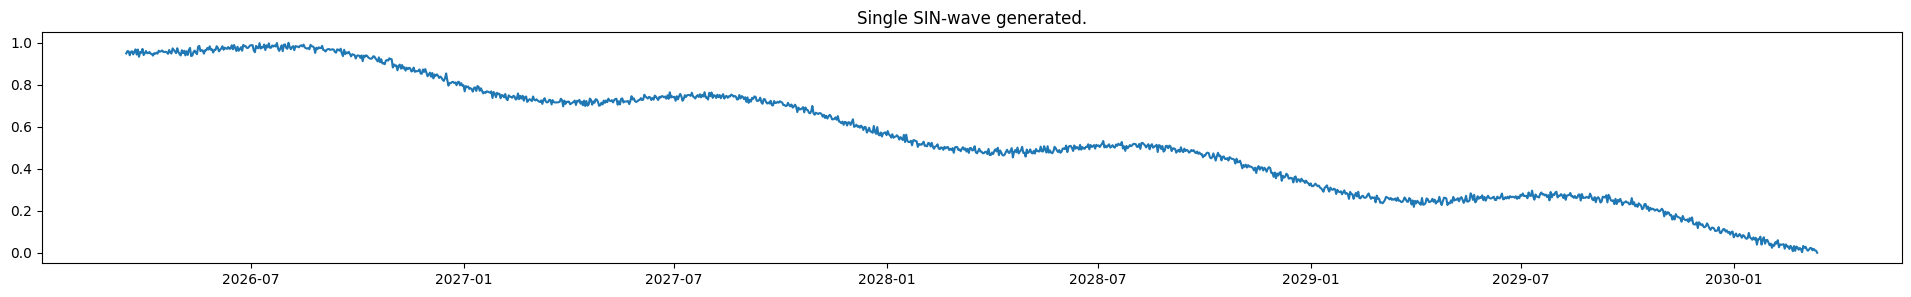

In [ ]:
n_years = np.random.randint(1, 15)
frequency = 2 * np.pi / 365.25

beta = 1
variation = False
elevation_power = 0
amplitude_change_power = 0
noise_level = 10**-2


amplitude = np.random.randint(-100, 100)
phase_shift = np.random.randint(-180, 180)
period_starts = pd.Timestamp('now')
a = np.random.randint(-500, 500) / (n_years * 365.25)
b = np.random.randint(-100, 100)

duration_days = 365 * n_years
period_ends = period_starts + pd.Timedelta(days=duration_days)

x = np.linspace(1, duration_days, duration_days)

if not variation:
    y = amplitude * np.sin(frequency * x + phase_shift)
else:
    y = amplitude * (x**amplitude_change_power) * np.sin(x**beta * frequency + phase_shift)

y += a * x + b
y += -1 + x**elevation_power
x_date = pd.date_range(period_starts, period_ends, freq='D')[:-1]

if noise_level:
    min_, max_ = y.min(), y.max()
    y = normalize(y, min_, max_)
    y += noise_level * np.random.randn(len(y))
    y = normalize(y)


plt.figure(figsize=(24,3))
plt.plot(x_date, y)
plt.title('Single SIN-wave generated.')
plt.show()
x_train, x_test, y_train, y_test = train_test_split(x.reshape(-1,1), y, shuffle=False)

# Torch

## Definitions

In [263]:
import torch
import torch.nn.functional as F
import tqdm
device = 'cuda'

In [264]:
def torch_least_squares_simple(x, y) -> tuple:
    '''
    Both x and y are 1D arrays
    returns (a, b) from y = ax + b
    '''
    n = len(x)
    sum_x = torch.sum(x)
    sum_y = torch.sum(y)
    sum_xy = torch.sum(x * y)
    sum_x2 = torch.sum(x**2)
    denominator = n * sum_x2 - sum_x**2
    a = (n * sum_xy - sum_x * sum_y) / denominator
    b = (sum_y * sum_x2 - sum_x * sum_xy) / denominator
    return a, b

   
def normalize_torch(
    array: torch.Tensor,
    min_: float = None,
    max_: float = None
):
    if len(torch.unique(array)) == 1:
        value = torch.unique(array)[0]
        norm_value = 0.5
        if max_ != min_:
            norm_value = (value - min_) / (max_ - min_)
        return torch.ones_like(array) * norm_value    
    if min_ is None:
        min_ = array.min()
    if max_ is None:
        max_ = array.max()        
    return (array - min_) / (max_ - min_)


def denormalize_torch(
    normalized_array: torch.Tensor,
    min_: float,
    max_: float
) -> torch.Tensor:
    return normalized_array * (max_ - min_) + min_


def freeze_parameters(model, whitelist):
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if name in whitelist:
            param.requires_grad = True


def get_max_gap_torch(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.max() if runs.numel() > 0 else 0


def get_median_gap_torch(bool_vec: torch.Tensor) -> int:
    z = (~bool_vec).int()
    p = torch.cat([torch.tensor([0], device=bool_vec.device), z, torch.tensor([0], device=bool_vec.device)])
    runs = (torch.diff(p) == -1).nonzero(as_tuple=True)[0] - (torch.diff(p) == 1).nonzero(as_tuple=True)[0]
    return runs.median() if runs.numel() > 0 else 0


def rolling_mean_centered_unbiased(x, window):
    x = x.unsqueeze(0).unsqueeze(0)  # (1,1,N)
    kernel = torch.ones(1, 1, window, device=x.device, dtype=x.dtype)
    pad = window // 2
    sums = F.conv1d(x, kernel, padding=pad)
    counts = F.conv1d(torch.ones_like(x), kernel, padding=pad)
    return (sums / counts).squeeze()

In [265]:
# import numpy as np
# x = np.arange(100) / 1
# y = 2*x + 3
# noise_level = 0.1
# y *= 1 + noise_level * np.random.randn(len(y))

# a, b = torch_least_squares_simple(torch.tensor(x), torch.tensor(y))
# y_pred = a.item() * x + b.item()
# plt.plot(x, y)
# plt.plot(x, y_pred)

In [266]:
class LinearLSQR(torch.nn.Module):
    def __init__(self, x, y, device):
        super().__init__()
        self.slope, self.intercept = torch_least_squares_simple(x, y)
        self.slope.to(device)
        self.intercept.to(device)

    def forward(self, x):
        return self.slope * x + self.intercept

class SineNN(torch.nn.Module):
    def __init__(self, x, y, device, auto_frequency_sensitivity=0.001):
        super().__init__()
        self.auto_frequency_sensitivity = auto_frequency_sensitivity
        # n = y.numel()
        linlsqr = LinearLSQR(x, y, device)
        self.slope, self.intercept = linlsqr.slope, linlsqr.intercept
        self.line = linlsqr(x)
        y_horizontal = y - linlsqr(x)
        self.hmin, self.hmax = y_horizontal.min(), y_horizontal.max()
        y_hornorm = normalize_torch(y_horizontal) - 0.5
        y_hornorm_rolling = rolling_mean_centered_unbiased(y_hornorm, 10)

        # approx_max_freq = (y_hornorm.abs() <=  self.auto_frequency_sensitivity).sum() / len(y)
        bool_vec = y_hornorm_rolling.abs() <=  self.auto_frequency_sensitivity
        self.middle_density = bool_vec.sum()
        approx_min_freq = torch.pi / get_max_gap_torch(bool_vec)
        approx_max_freq = torch.pi / get_median_gap_torch(bool_vec)
        # single_wave = 2 * torch.pi / len(y)
        # self.amplitude = torch.nn.Parameter(torch.tensor(0.5))
        self.amplitude = torch.tensor(0.5)
        self.frequency = torch.nn.Parameter(approx_min_freq.to(float))              
        self.phase = torch.nn.Parameter(torch.tensor(0.5))
        self.min_frequency = approx_min_freq
        self.max_frequency = approx_max_freq
        # self.frequency_bound = self.bind_frequency()
        # self.frequency = torch.log(self.frequency_raw)

    def bind_frequency(self):
        # minmax_range = self.max_frequency - self.min_frequency
        # frequency = self.min_frequency + torch.sigmoid(self.frequency) * minmax_range
        # frequency = frequency * minmax_range + self.min_frequency
        frequency = torch.clamp(self.frequency, self.min_frequency, self.max_frequency)
        return frequency
        
    def forward(self, x):
        sin_wave_hornorm = self.amplitude * torch.sin(self.bind_frequency() * x + self.phase)
        sin_wave_horizontal = denormalize_torch(sin_wave_hornorm + 0.5, self.hmin, self.hmax)
        sin_wave = sin_wave_horizontal + self.line
        bool_vec = sin_wave_hornorm.abs() <=  self.auto_frequency_sensitivity
        middle_density = bool_vec.sum()
        return sin_wave, middle_density

## Run

tensor(155, device='cuda:0')


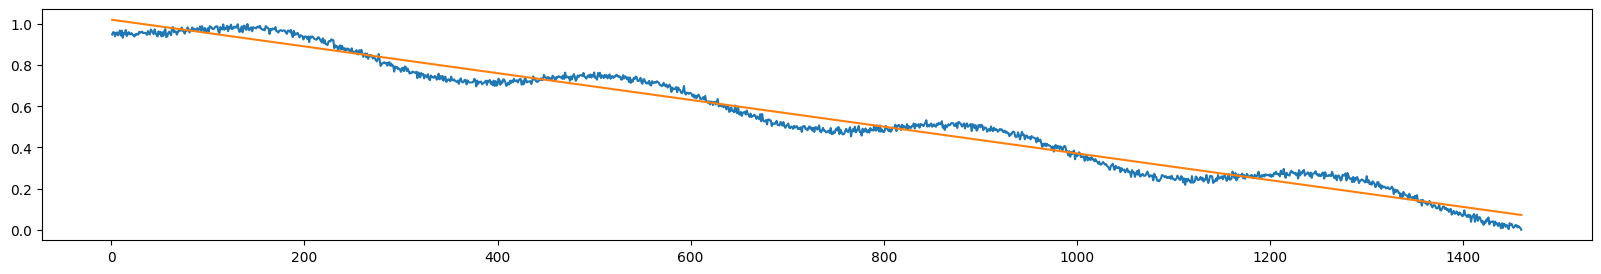

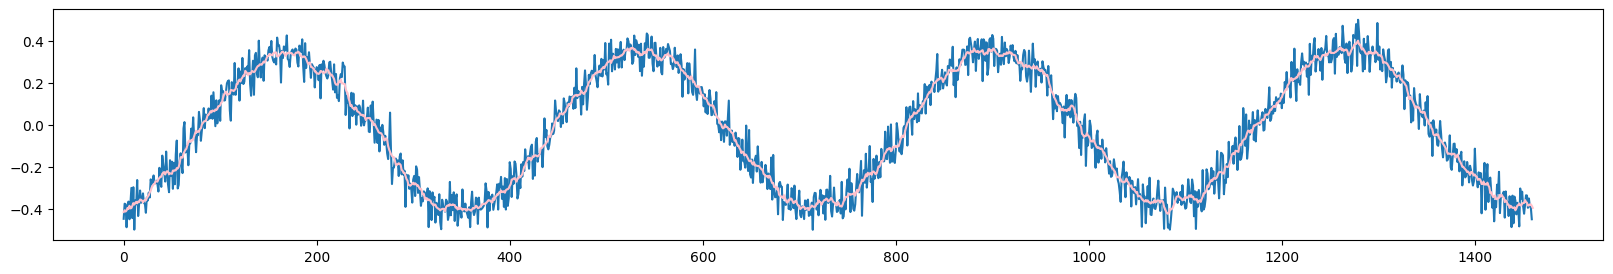

In [267]:
linlsqr = LinearLSQR(torch.tensor(x, device=device), torch.tensor(y, device=device), device)
line_pred = linlsqr(torch.tensor(x, device=device))
y_horizontal = torch.tensor(y, device=device) - line_pred
y_hornorm = normalize_torch(y_horizontal) - 0.5
y_hornorm_rolling = rolling_mean_centered_unbiased(y_hornorm, 10)

epsilon = 0.01
bool_vec = y_horizontal.abs() <= epsilon
print(get_max_gap_torch(bool_vec))

plt.figure(figsize=(20, 3))
plt.plot(x, y)
plt.plot(x, line_pred.cpu())
plt.show()

plt.figure(figsize=(20, 3))
plt.plot(y_hornorm.cpu())
plt.plot(y_hornorm_rolling.cpu(), color='pink')


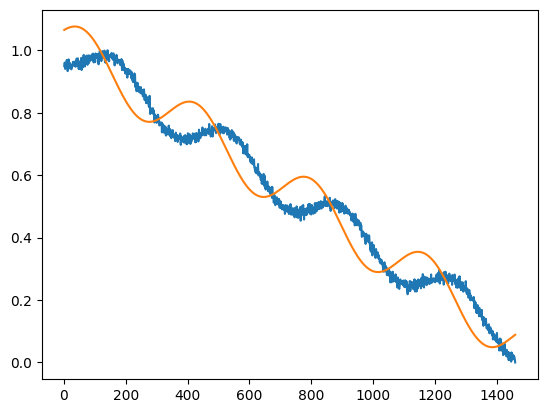

In [268]:
sinenn = SineNN(torch.tensor(x, device=device), torch.tensor(y, device=device), device, auto_frequency_sensitivity=0.01).to(device)
y_sinenn, middle_density = sinenn(torch.tensor(x, device=device))
y_sinenn = y_sinenn.detach().cpu().numpy()
plt.plot(x, y)
plt.plot(x, y_sinenn)

In [269]:
def get_sinenn_wave(
    x, y, device,
    steps_phase: int = 25,
    steps_freq: int = 100,
    iterations: int = 5,
):
    x = torch.tensor(x, device=device)
    y = torch.tensor(y, device=device)
    sinenn = SineNN(x, y, device, auto_frequency_sensitivity=0.01).to(device)

    history = []
    for iteration in tqdm.tqdm(range(iterations)):
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=0.1)
        freeze_parameters(sinenn, whitelist=['phase'])
        for step in range(steps_phase):
            optimizer.zero_grad()
            y_hat, middle_density_hat = sinenn(x)
            loss = torch.mean((y_hat - y) ** 2)
            loss.backward()
            optimizer.step()
            history.append(loss)

        freeze_parameters(sinenn, whitelist=['frequency'])
        optimizer = torch.optim.Adam(sinenn.parameters(), lr=0.0001)
        for step in range(steps_freq):
            optimizer.zero_grad()
            y_hat, middle_density_hat = sinenn(x)
            density_loss = torch.sigmoid((middle_density_hat - sinenn.middle_density) / sinenn.middle_density) ** 2
            loss = torch.mean((y_hat - y) ** 2) + density_loss
            loss.backward()
            optimizer.step()
            history.append(loss)

    plt.plot([i.item() for i in history])
    return sinenn

In [270]:
sinenn._parameters

{'frequency': Parameter containing:
 tensor(0.0170, device='cuda:0', dtype=torch.float64, requires_grad=True),
 'phase': Parameter containing:
 tensor(0.5000, device='cuda:0', requires_grad=True)}

100%|██████████| 5/5 [00:00<00:00, 13.07it/s]


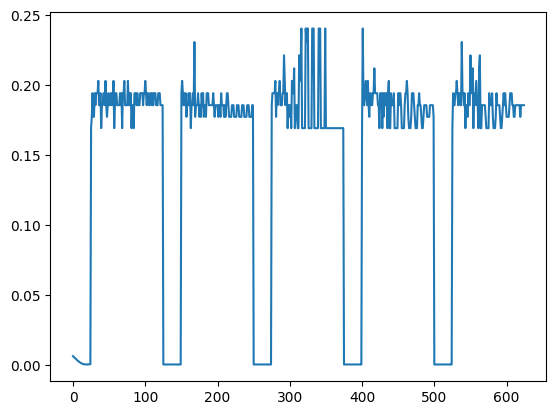

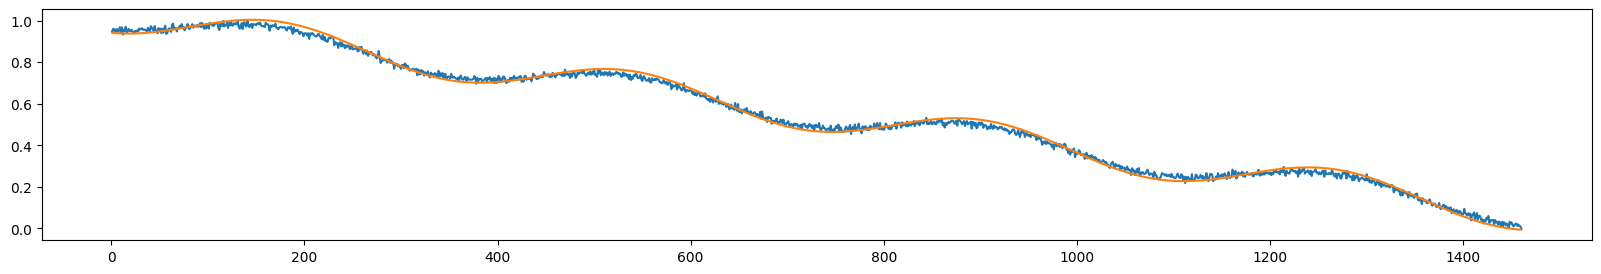

100%|██████████| 5/5 [00:00<00:00, 11.30it/s]


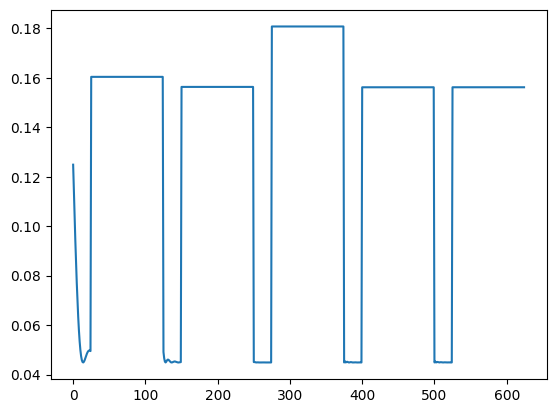

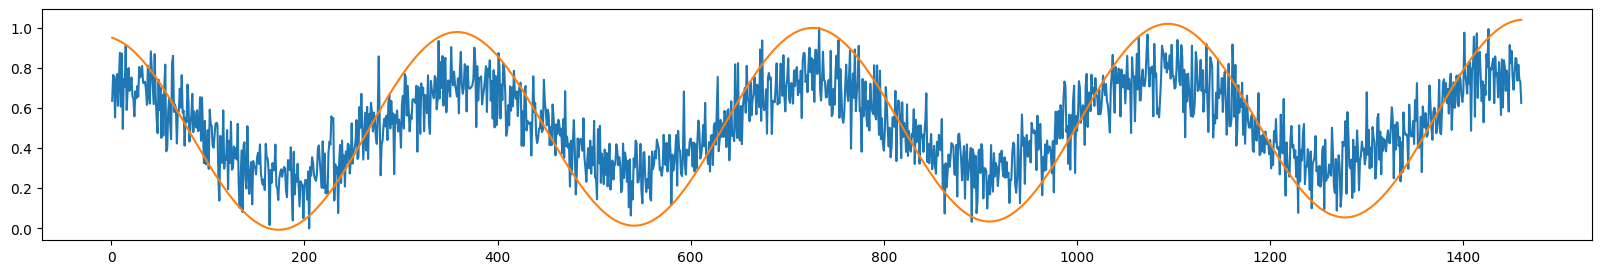

100%|██████████| 5/5 [00:00<00:00, 11.96it/s]


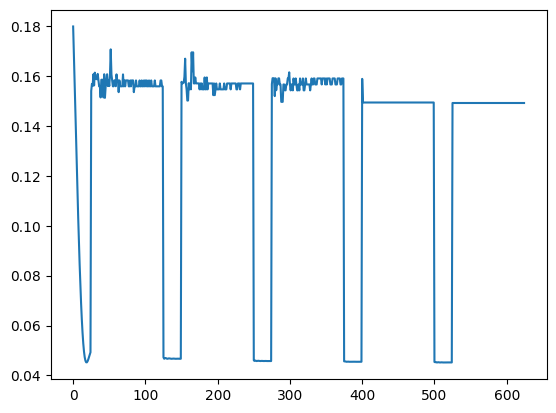

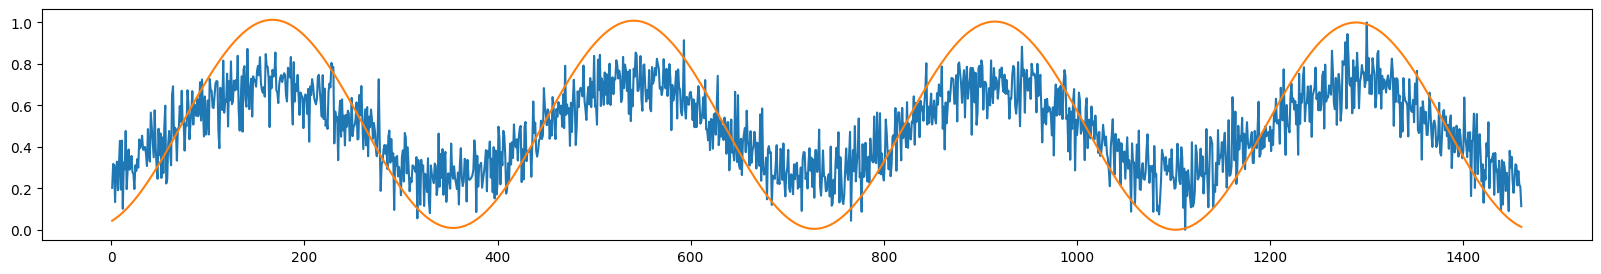

100%|██████████| 5/5 [00:00<00:00, 12.55it/s]


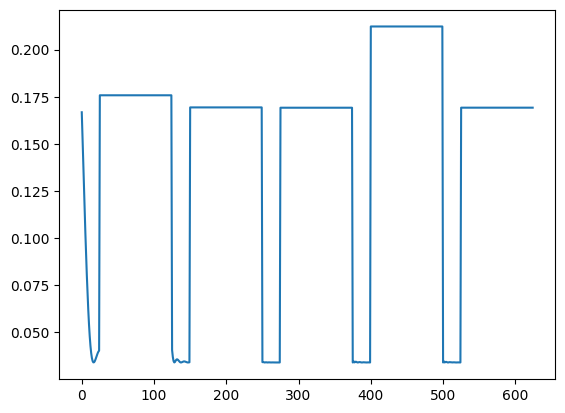

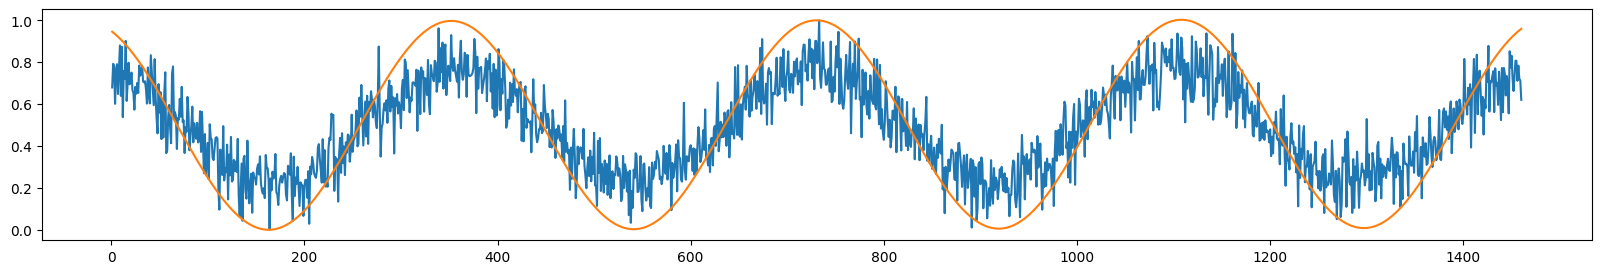

100%|██████████| 5/5 [00:00<00:00, 12.02it/s]


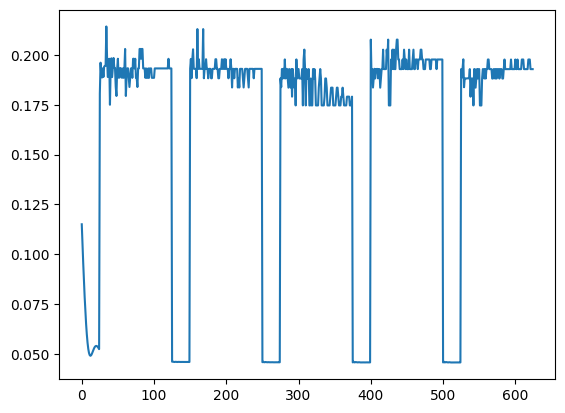

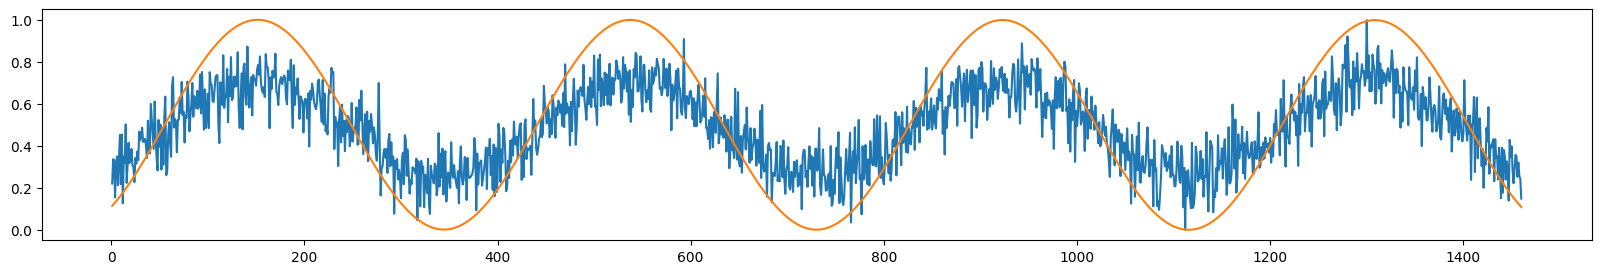

100%|██████████| 5/5 [00:00<00:00, 11.59it/s]


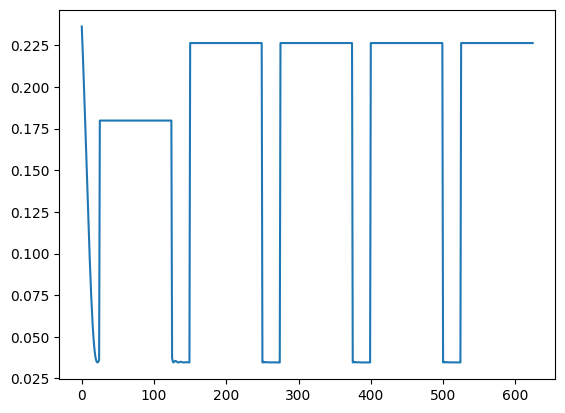

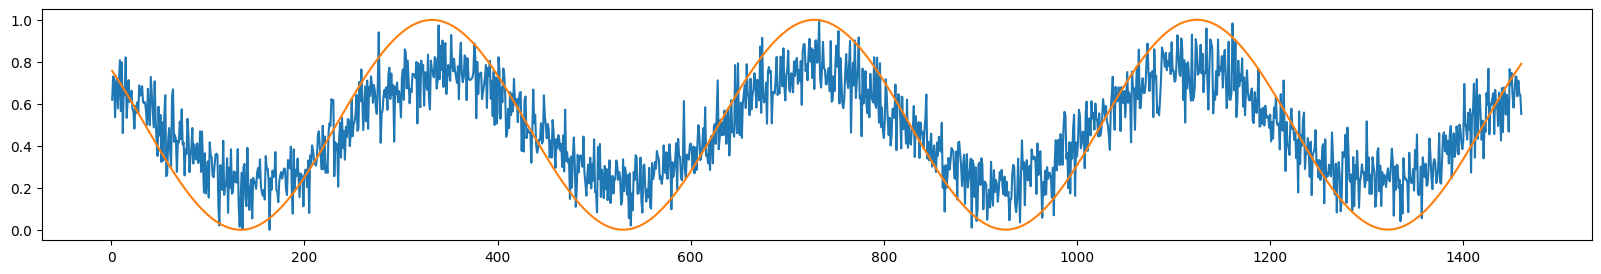

100%|██████████| 5/5 [00:00<00:00, 11.71it/s]


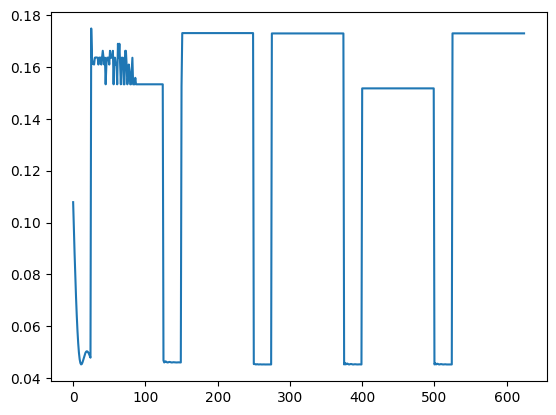

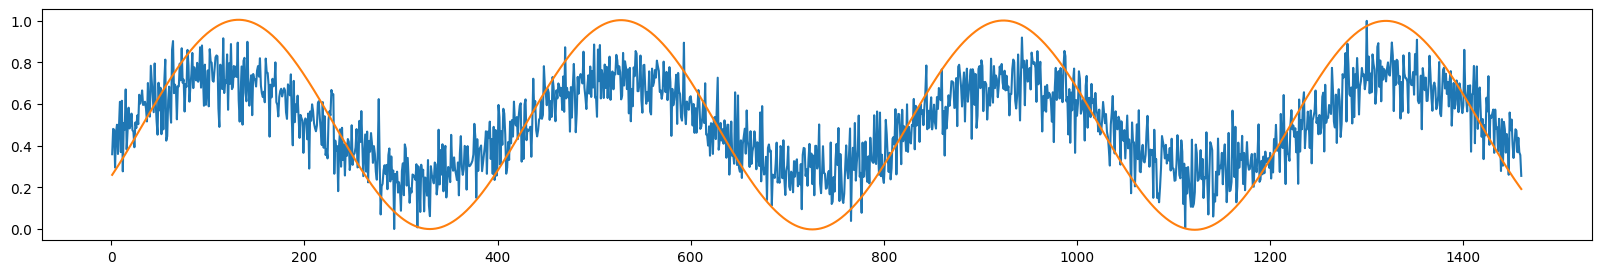

100%|██████████| 5/5 [00:00<00:00, 11.08it/s]


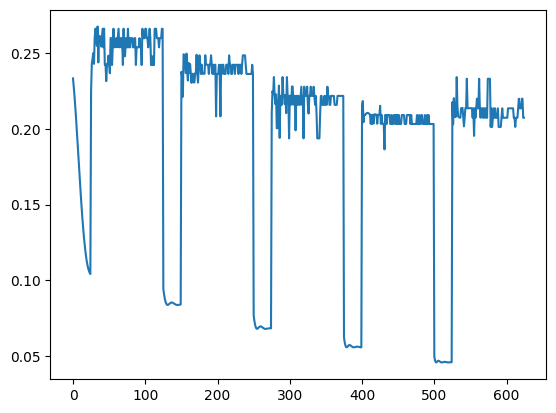

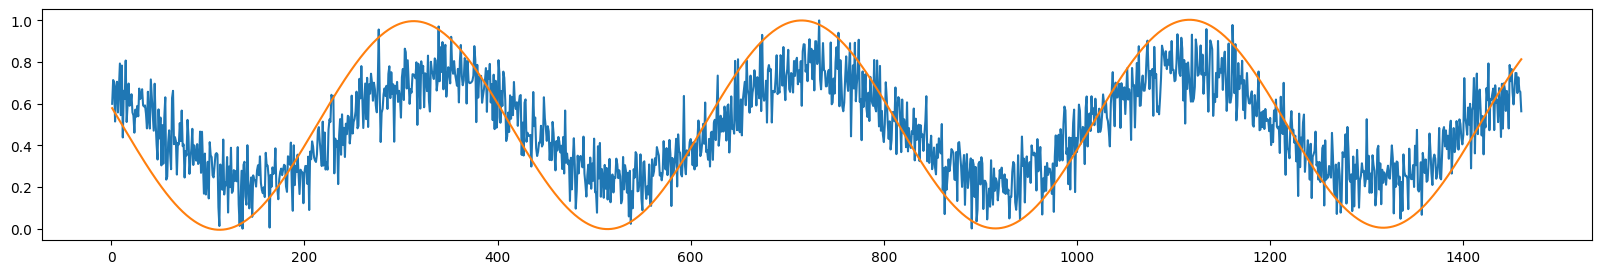

100%|██████████| 5/5 [00:00<00:00, 11.66it/s]


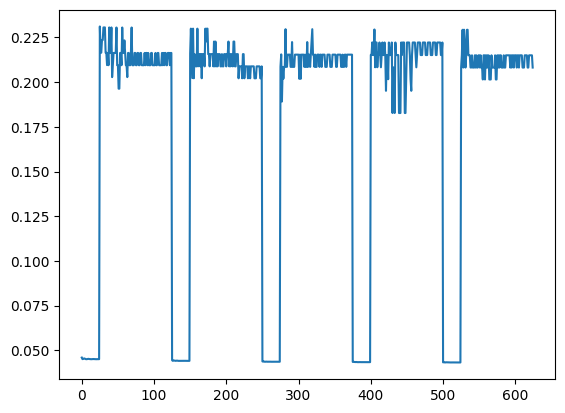

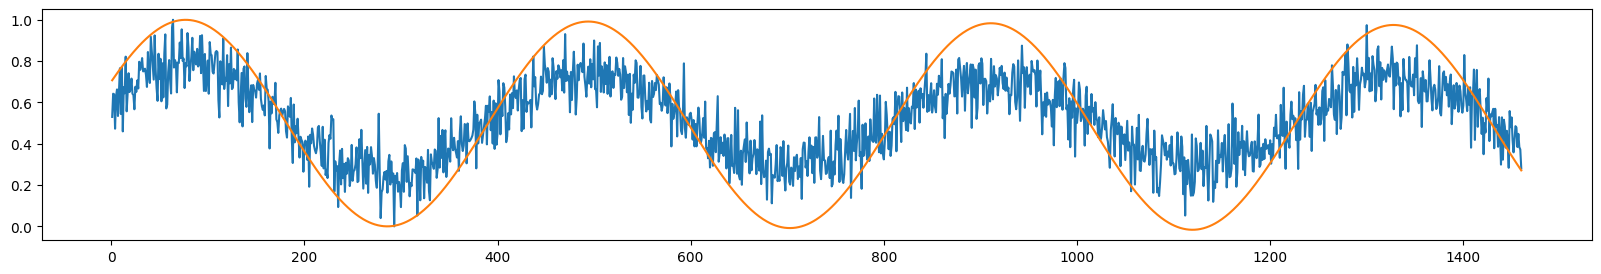

100%|██████████| 5/5 [00:00<00:00, 11.41it/s]


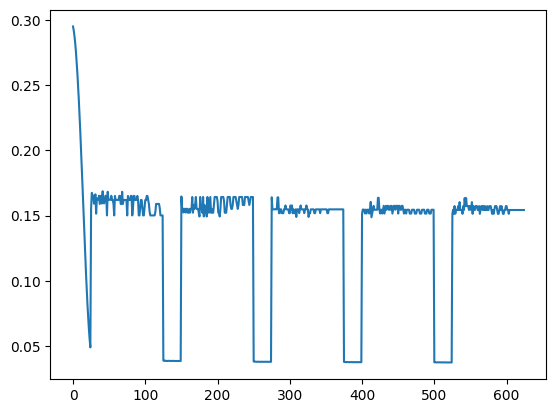

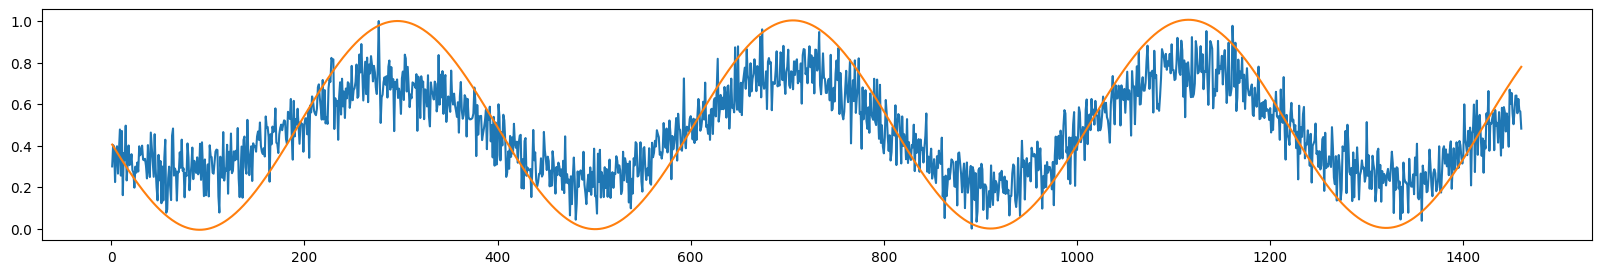

In [271]:
for _ in range(10):
    sinenn = get_sinenn_wave(x, y, device)
    y_sinenn, middle_density = sinenn(torch.tensor(x, device=device))
    y_sinenn = y_sinenn.detach().cpu().numpy()
    plt.figure(figsize=(20, 3))
    plt.plot(x, y)
    plt.plot(x, y_sinenn)
    plt.show()
    y = normalize(y-y_sinenn)

# Old (FFT)

In [272]:
1/0

ZeroDivisionError: division by zero

In [ ]:
class SineNN_FFT(torch.nn.Module):
    def __init__(self, y):
        super().__init__()
        device = y.device
        
        N = y.shape[0]
        Yf = torch.fft.fft(y)
        freqs = torch.fft.fftfreq(N)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1
        
        ampl0 = 2 * mag[peak_idx] / N
        phase0 = torch.angle(Yf[peak_idx])
        c0 = y.mean()
        
        self.a = torch.nn.Parameter(torch.tensor(ampl0, device=device))
        self.b = torch.nn.Parameter(torch.tensor(phase0, device=device))
        self.c = torch.nn.Parameter(torch.tensor(c0, device=device))
        
    def forward(self, x):
        return self.a * torch.sin(x + self.b) + self.c

In [ ]:
model = SineNN_FFT(y_train).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for _ in tqdm.tqdm(range(1000)):
    optimizer.zero_grad()
    (loss := torch.mean((model(x_train) - y_train)**2)).backward()
    optimizer.step()

print(model.a.item(), model.b.item(), model.c.item())


x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)
y_pred = model(x_test_tensor).detach().cpu().numpy()

TypeError: fft_fft(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

In [ ]:
class FFTPredictor:
    def __init__(self, y: torch.Tensor):
        """
        y: 1D tensor (float32) signal to analyze
        Computes amplitude, phase, and offset from FFT
        """
        N = y.shape[0]

        Yf = torch.fft.fft(y)
        mag = torch.abs(Yf[:N//2])
        peak_idx = torch.argmax(mag[1:]) + 1  # skip DC

        self.ampl = 2 * mag[peak_idx] / N
        self.phase = torch.angle(Yf[peak_idx])
        self.offset = y.mean()

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: input tensor of positions
        Returns predicted sine values using FFT-estimated parameters
        """
        return self.ampl * torch.sin(x + self.phase) + self.offset

In [ ]:
torch.fft.fft(y_train_tensor)

tensor([831.6422+0.0000j, -16.7095+108.0916j, -18.8377+59.8880j,
         ..., -23.9169-49.2210j, -18.8377-59.8880j,
        -16.7095-108.0916j], device='cuda:0')

In [ ]:
device = "cuda"
x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32, device=device)

fft_pred = FFTPredictor(y_train_tensor)
y_pred = fft_pred.predict(x_test_tensor)

/tmp/ipykernel_17362/231372252.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_train_tensor = torch.tensor(x_train, dtype=torch.float32, device=device)
/tmp/ipykernel_17362/231372252.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train_tensor = torch.tensor(y_train, dtype=torch.float32, device=device)


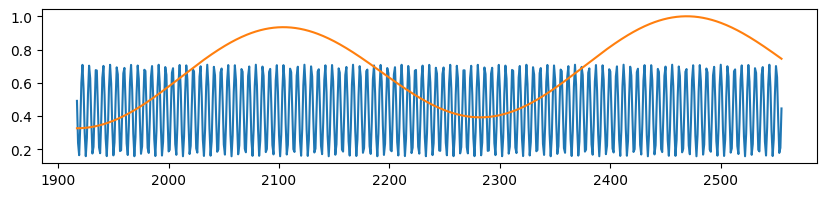

In [ ]:
plt.figure(figsize=(10, 2))
plt.plot(x_test, y_pred.cpu().detach().numpy())
plt.plot(x_test, y_test)